# Demand Curve Findings & Scenario Modeling

This notebook assembles the refreshed inverse demand artifacts, validates segments with counterintuitive elasticities, and layers in event-type and scenario analyses (season period & demographics) to guide pricing experiments.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.linear_model import LinearRegression

# Paths
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "master_tickets.csv"
FINDINGS_DIR = BASE_DIR / "demand_curve_findings"
SUMMARY_PATH = FINDINGS_DIR / "price_sensitivity_summary.csv"

summary_df = pd.read_csv(SUMMARY_PATH)
display(summary_df.head())


,segment,price_weighted_avg,observations,elasticity,r_squared,delta_q_+10pct,delta_rev_+10pct,delta_q_-10pct,delta_rev_-10pct,notes
0,Balcony (All buyers),31.63,89,0.125,0.001,0.012,0.113,-0.013,-0.112,Seat-specific sensitivity.
1,CYO Subscription (All seats),57.32,34,0.345,0.011,0.033,0.137,-0.036,-0.132,Bucket-level view.
2,Dress Circle (All buyers),50.30,74,0.932,0.059,0.093,0.202,-0.094,-0.184,Seat-specific sensitivity.
3,Fixed - Chorus (All seats),46.45,30,0.893,0.101,0.089,0.198,-0.090,-0.181,Fixed subscription detail.
4,Fixed - Established (All seats),58.03,67,0.485,0.017,0.047,0.152,-0.050,-0.145,Fixed subscription detail.


## Appendix: Ticket Price Summary


In [2]:
import pandas as pd
from IPython.display import display

ticket_df = pd.read_csv(DATA_PATH)
ticket_df = ticket_df[ticket_df["purchase_price"] > 0].copy()

buy_type_stats = (
    ticket_df.groupby("ticket_type")["purchase_price"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

seat_stats = (
    ticket_df.groupby("section_name")["purchase_price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .head(10)
    .reset_index()
)

summary = ticket_df[["purchase_price", "paid_amount", "num_seats", "days_before_event"]].describe()

print("Overall price metrics (paid tickets only):")
display(summary)

print("\nTicket type pricing summary:")
display(buy_type_stats)

print("\nTop seat sections by average price:")
display(seat_stats)


Overall price metrics (paid tickets only):


,purchase_price,paid_amount,num_seats,days_before_event
count,67974.000000,67974.000000,67974.000000,67393.000000
mean,55.255773,106.015713,1.917925,126.530426
std,28.486887,76.067399,0.947499,134.271641
min,5.000000,10.000000,1.000000,-175.000000
25%,34.000000,52.000000,1.000000,12.000000
50%,49.000000,90.000000,2.000000,62.000000
75%,70.000000,136.000000,2.000000,231.000000
max,275.000000,1615.000000,23.000000,463.000000



Ticket type pricing summary:


,ticket_type,count,mean,median,min,max
0,Single Ticket,34340,59.857277,55.0,5.0,275.0
1,Subscription,33199,51.023254,44.0,10.0,124.0



Top seat sections by average price:


,section_name,count,mean,median
0,PITR,28,105.714286,55.0
1,GA1,46,100.891304,95.0
2,PITL,32,91.562500,55.0
3,LOGER,4545,84.570407,83.0
4,LOGEL,5201,77.907018,76.0
5,ORCHL,22409,62.113073,55.0
6,DRESSR,1610,50.992857,51.0
7,ORCHR,20582,49.522590,47.0
8,DRESSL,2153,48.478611,47.0
9,BALCR,5138,32.142186,33.0


## 1. Snapshot of Inverse Demand Visuals
Key PNGs from `demand_curve_findings/` are embedded below for quick reference.


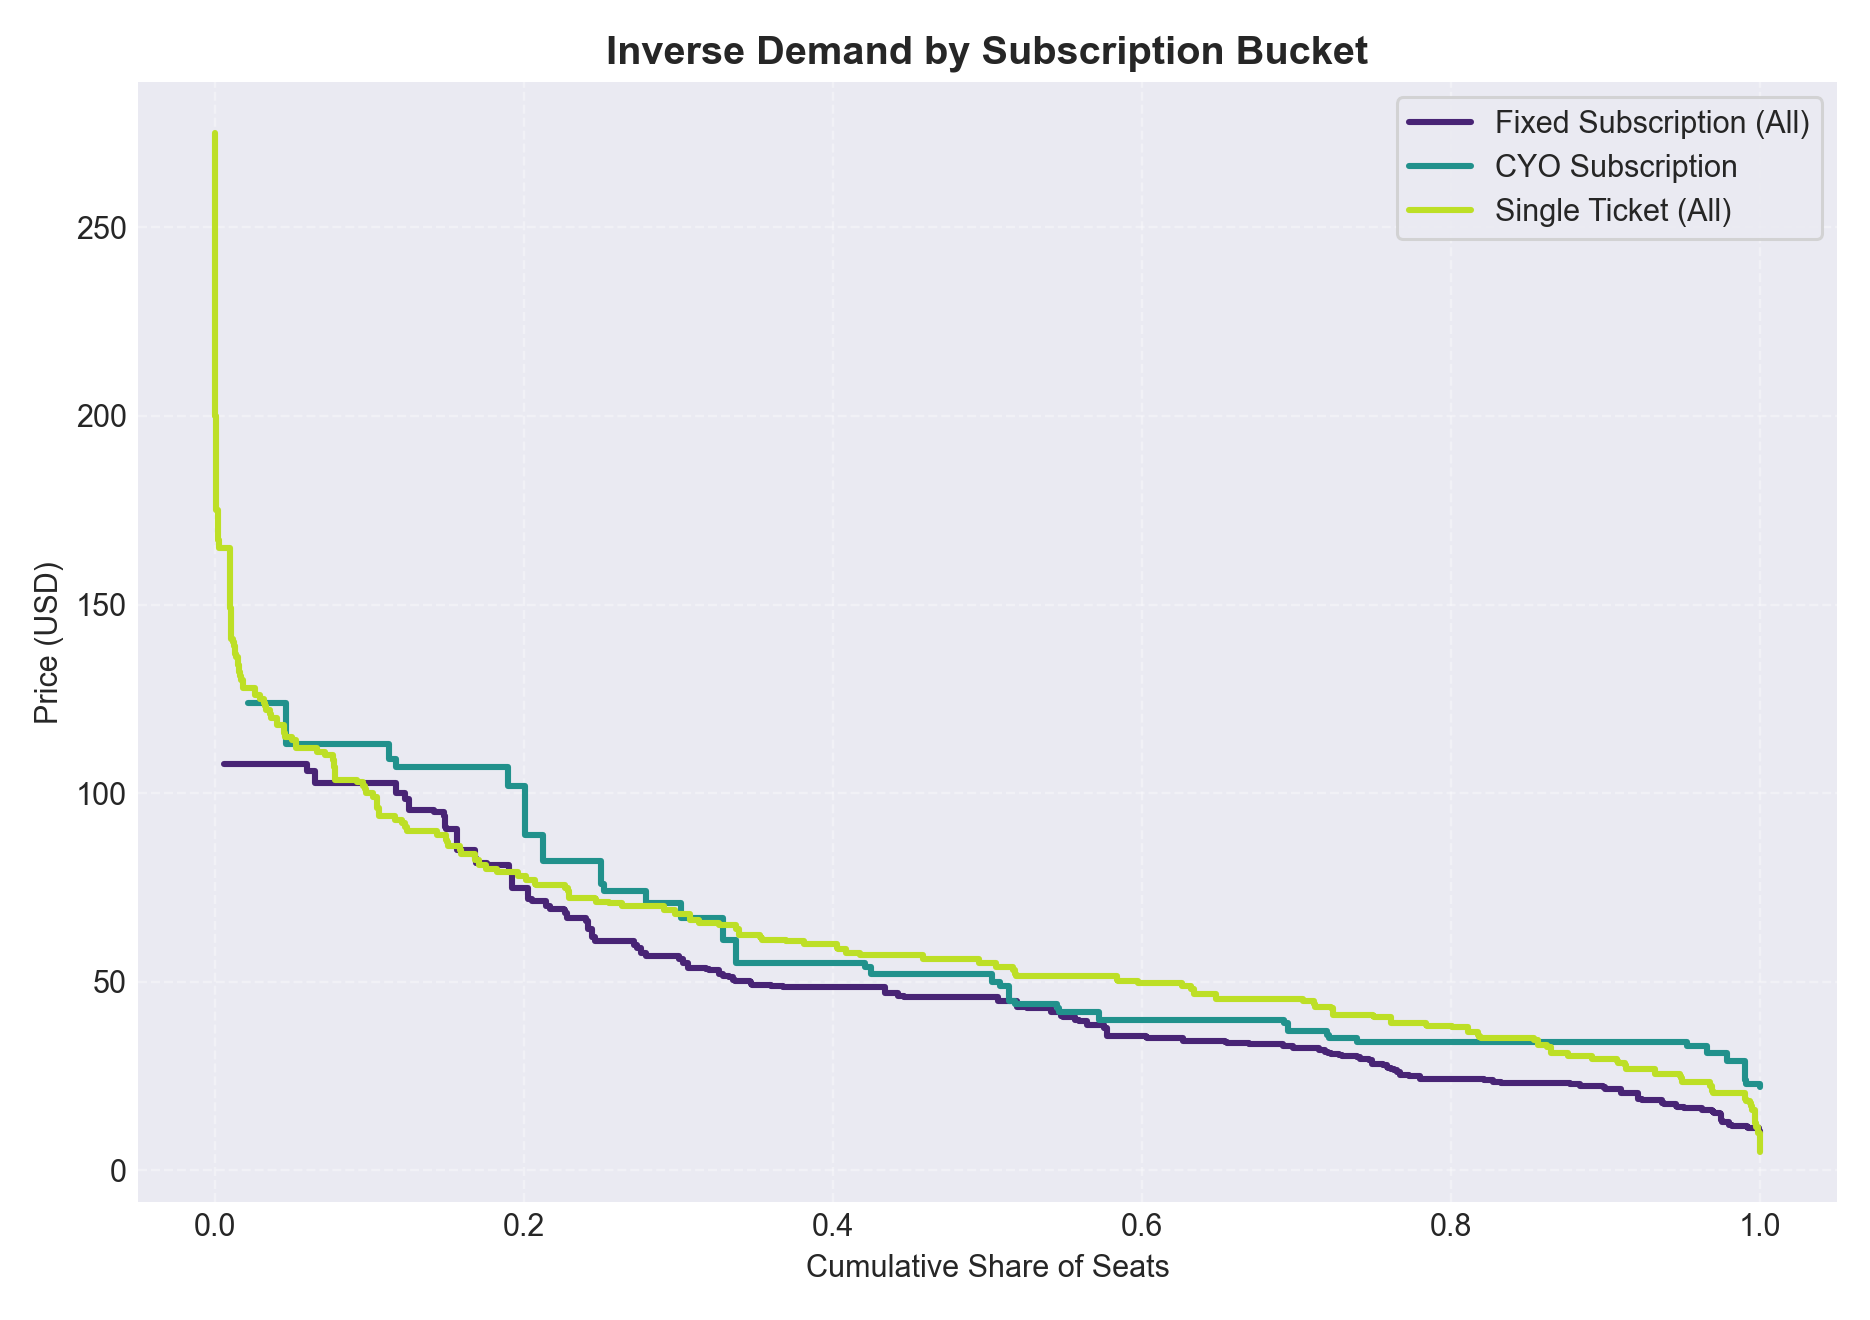

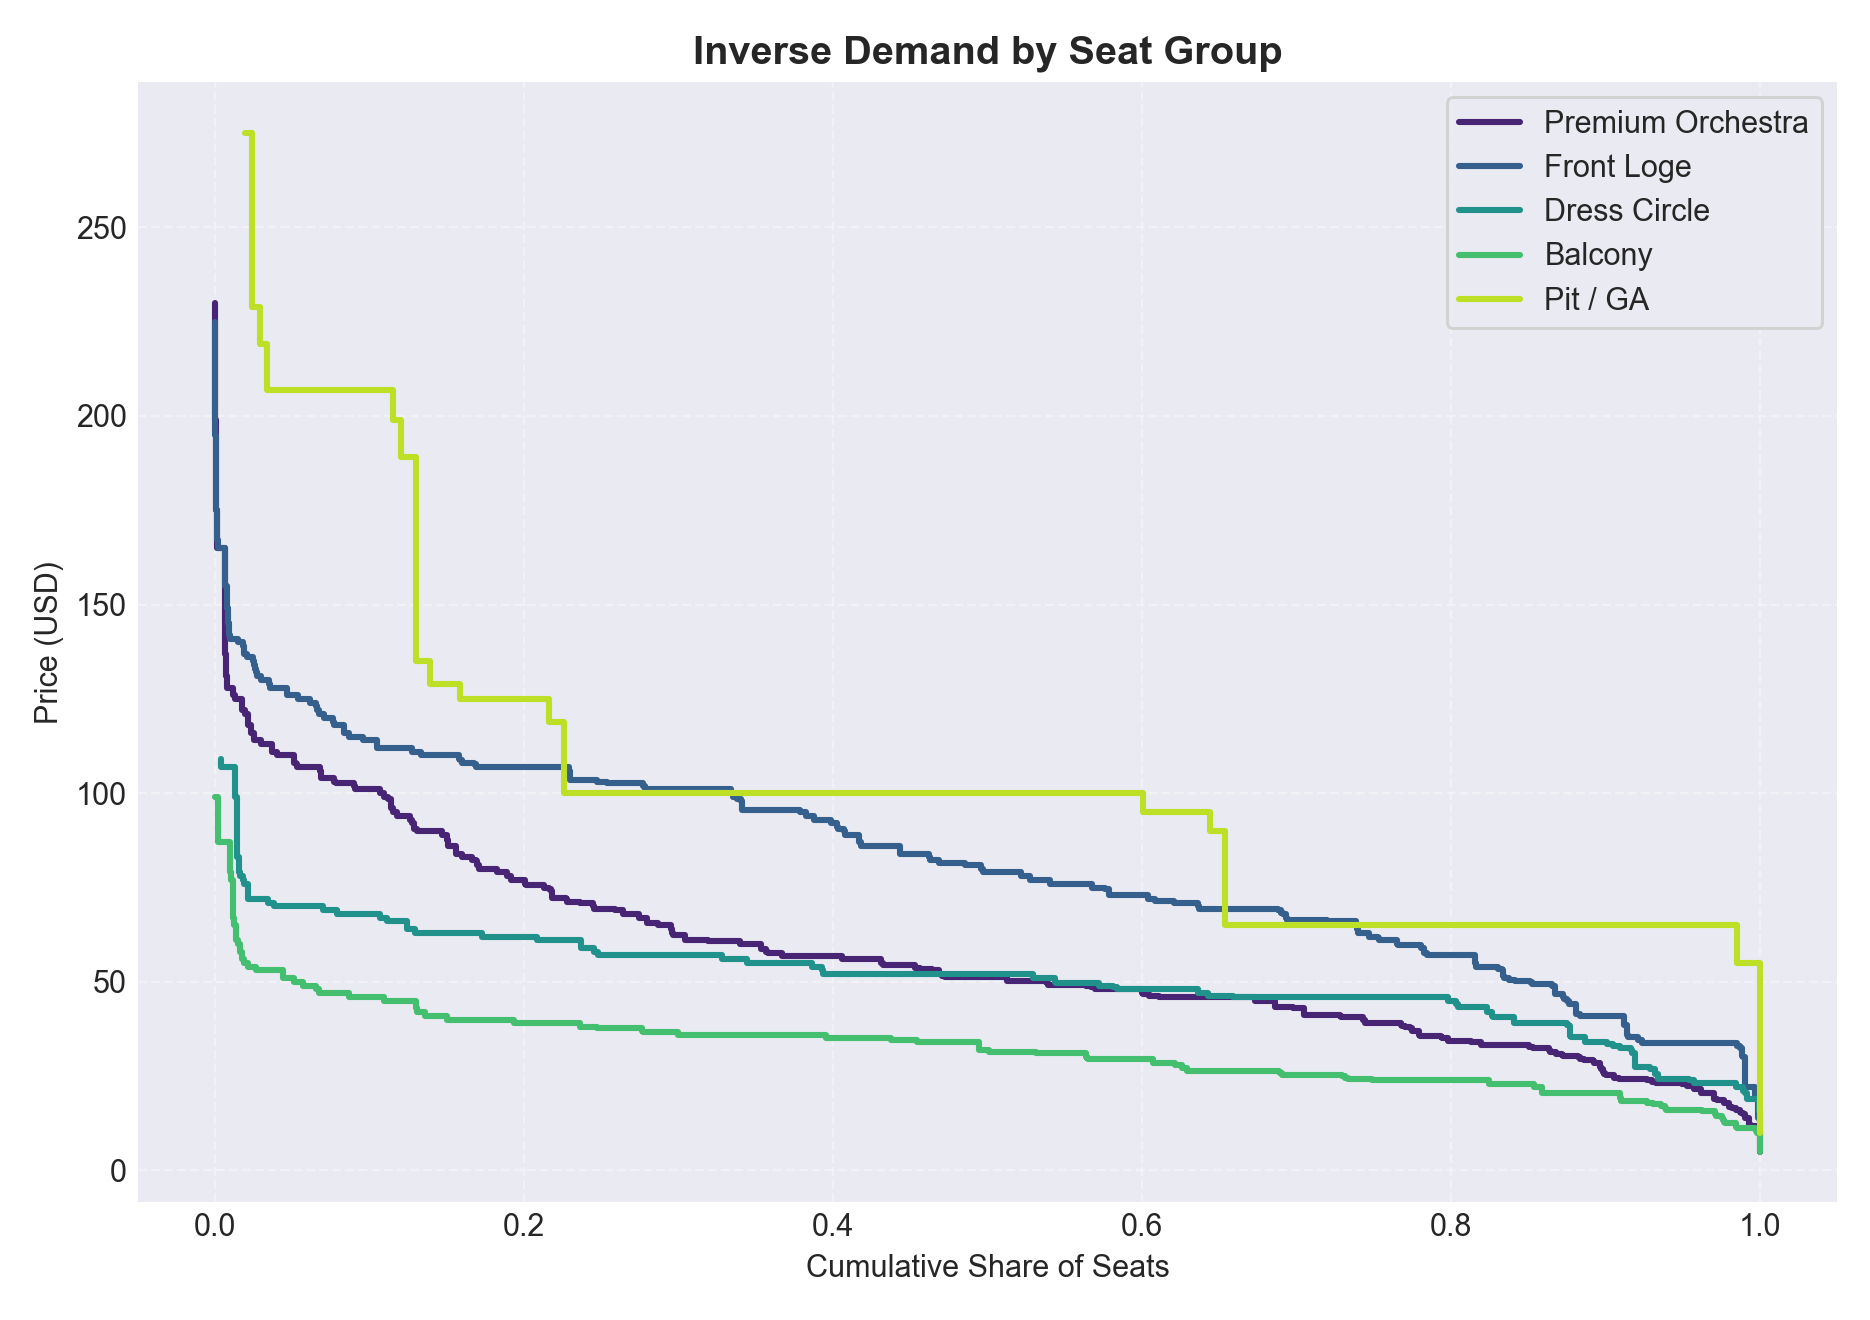

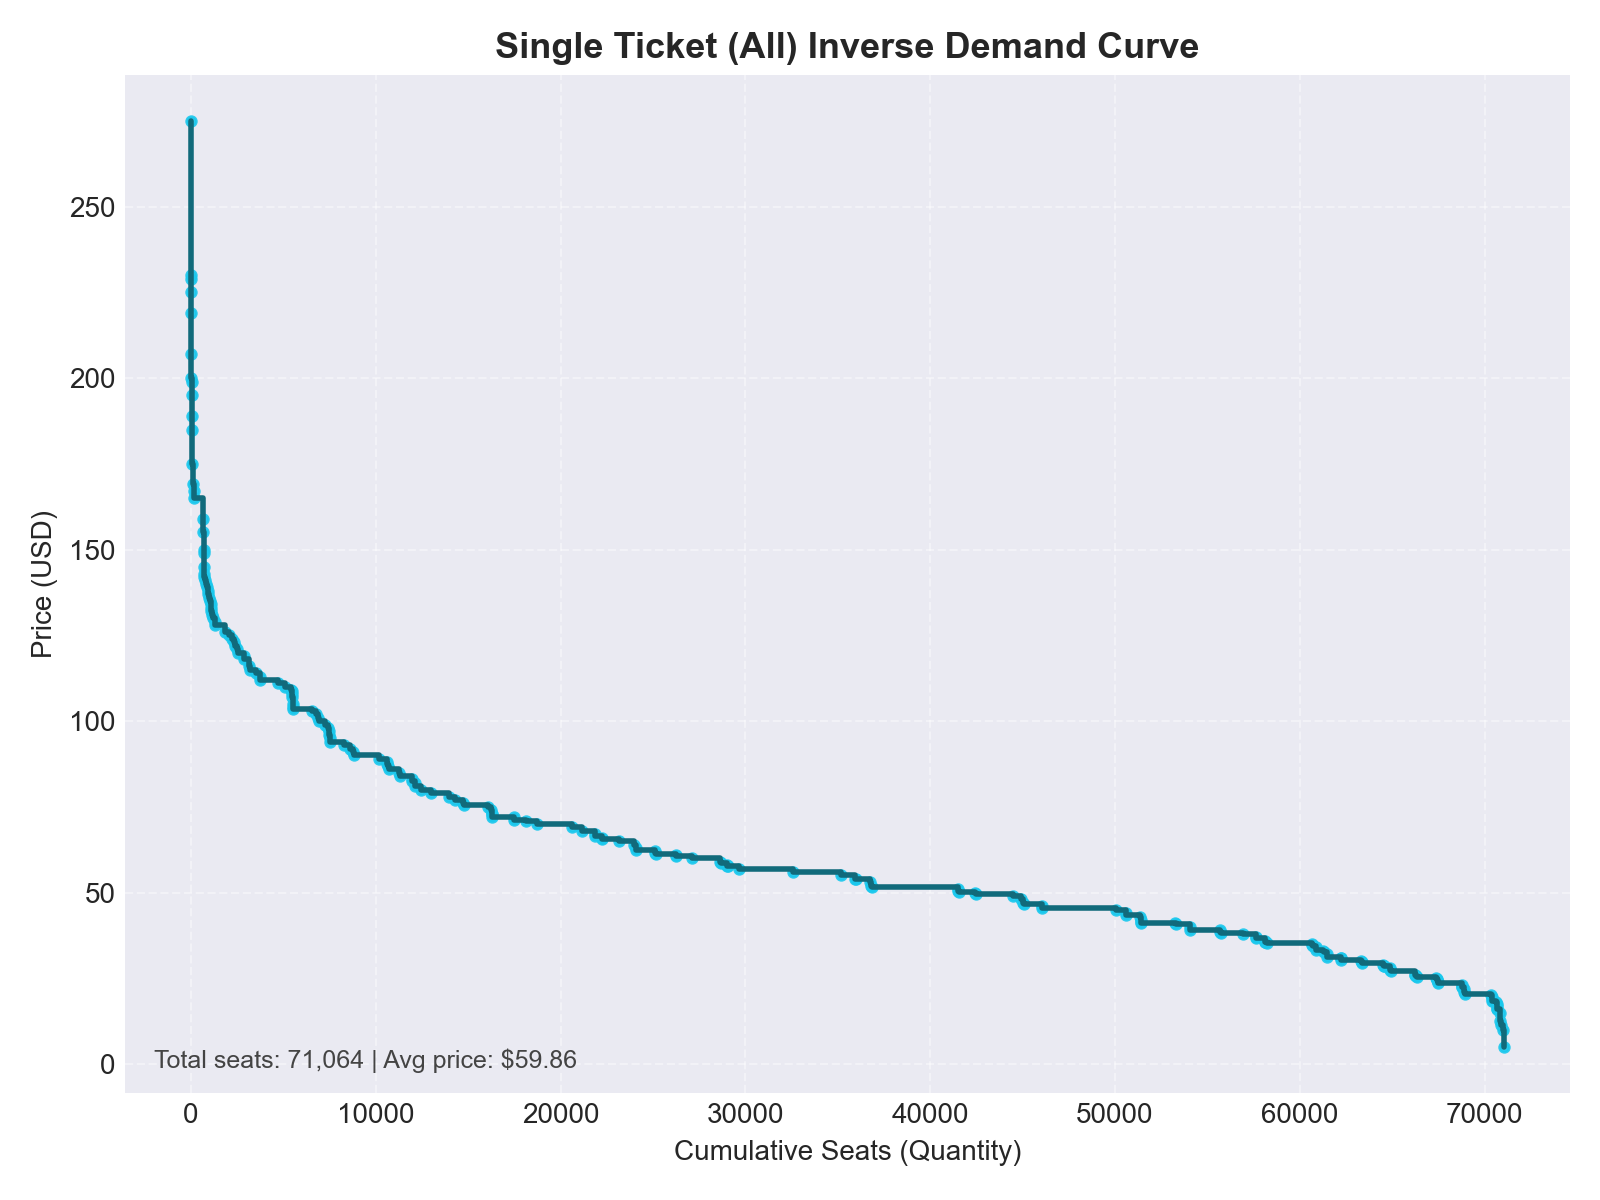

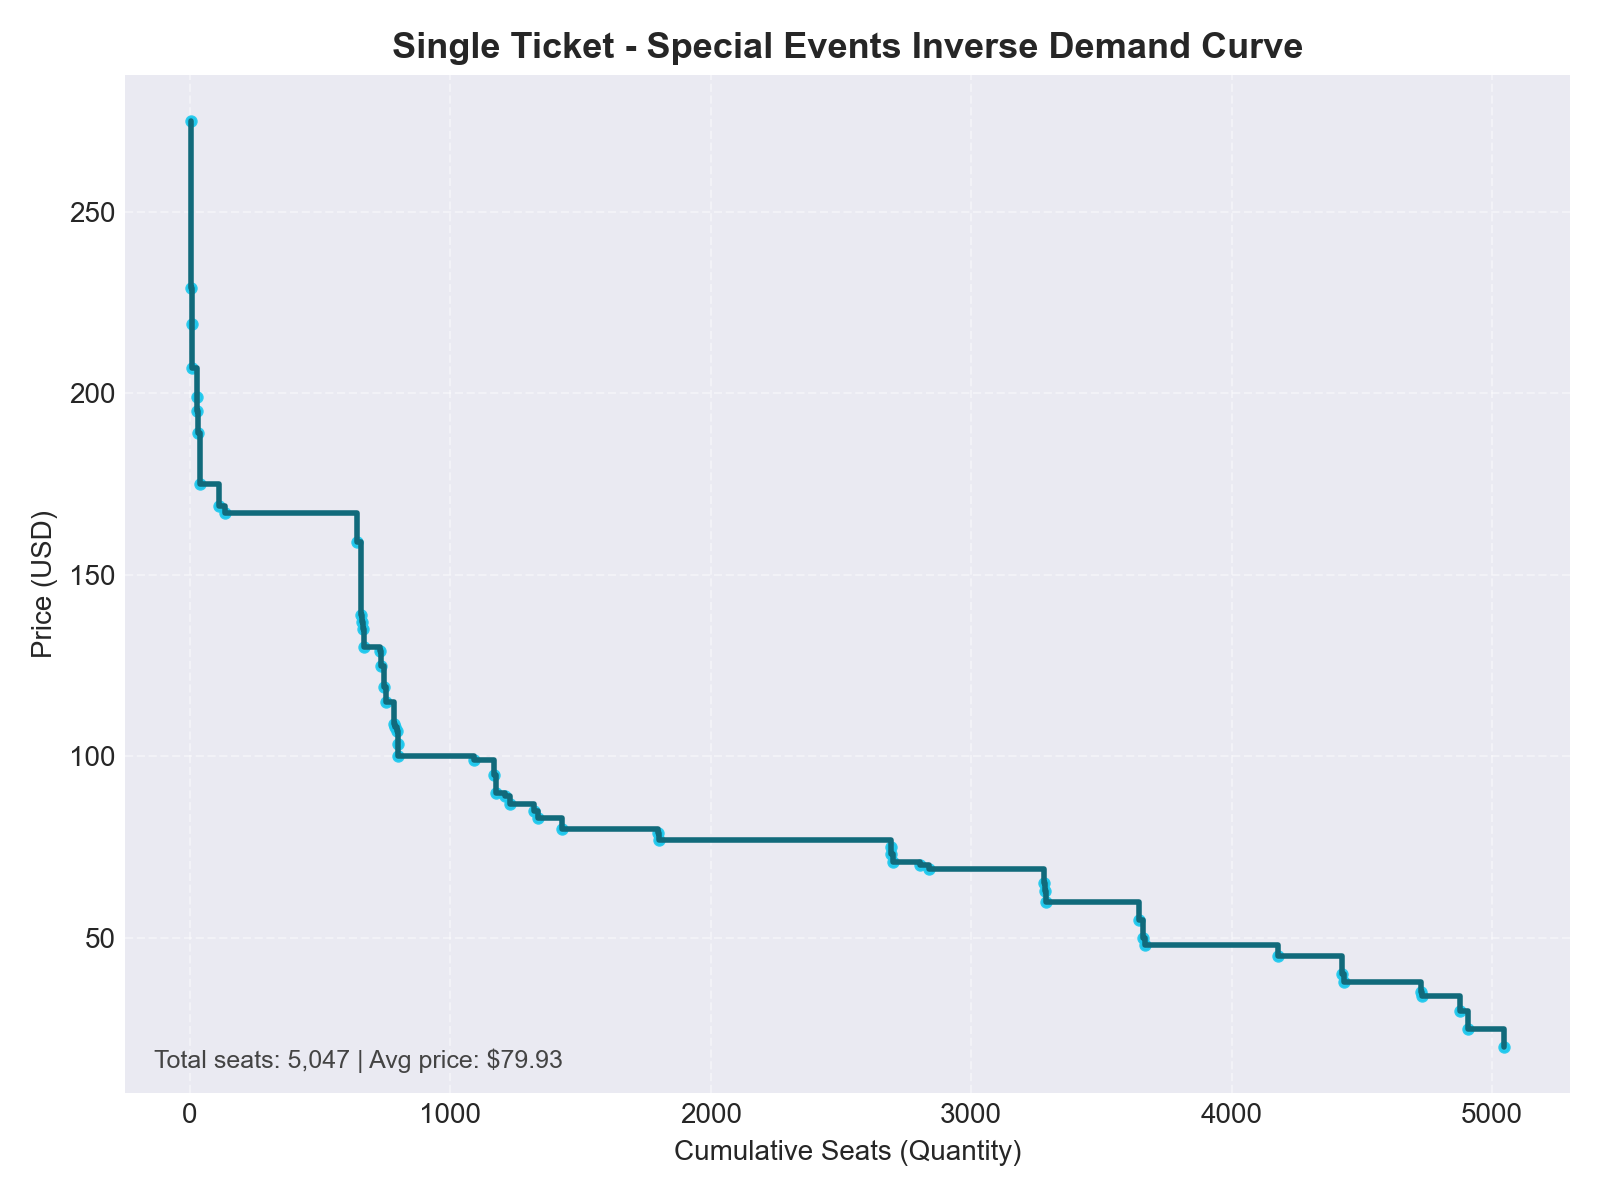

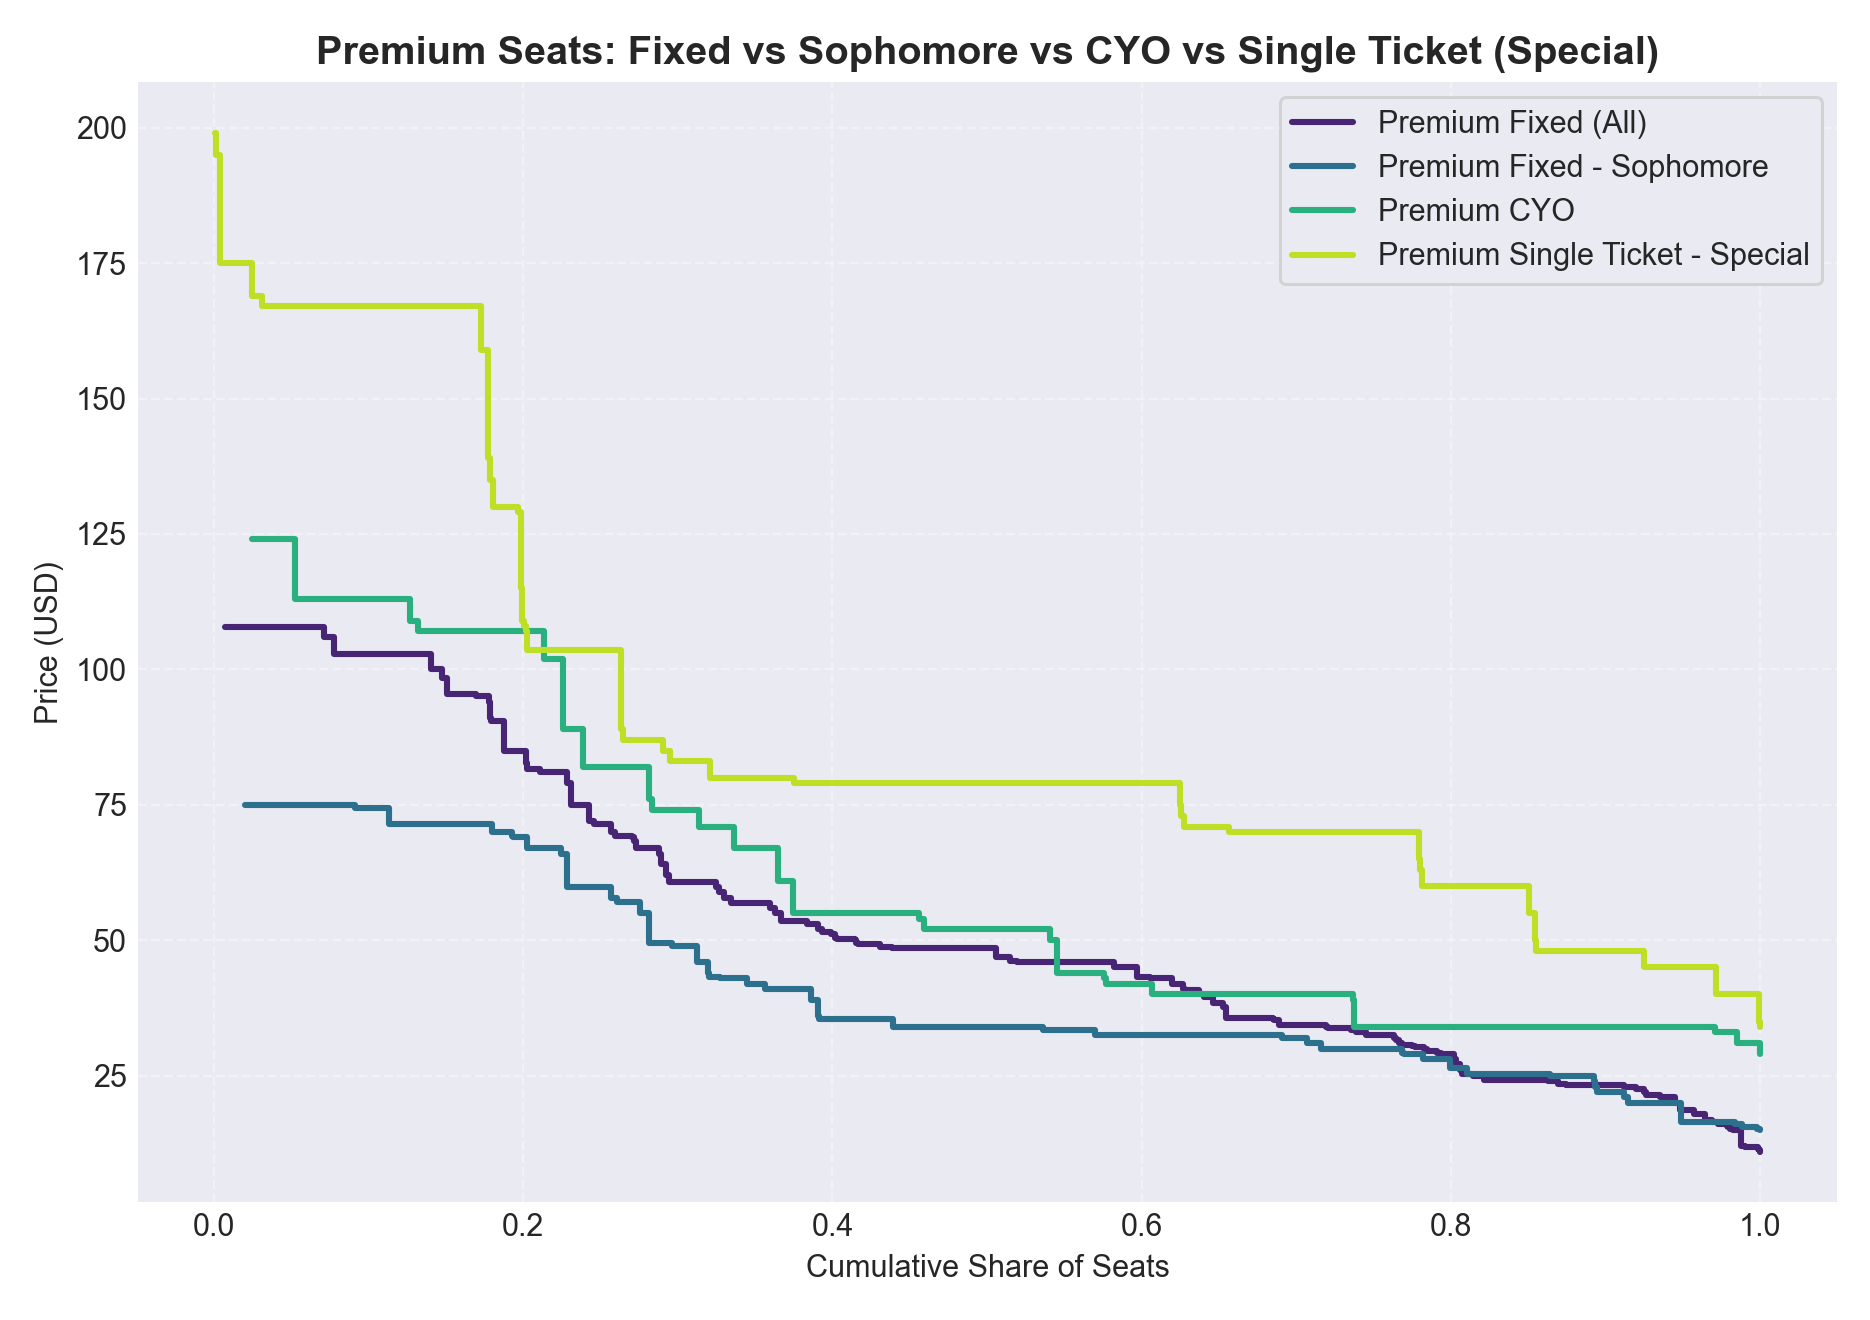

In [2]:
key_images = [
    "inverse_demand_subscription_bucket_overlay.png",
    "inverse_demand_by_seat_group.png",
    "inverse_demand_single_ticket_(all).png",
    "inverse_demand_single_ticket___special_events.png",
    "inverse_demand_premium_focus.png",
]

for img in key_images:
    path = FINDINGS_DIR / img
    if path.exists():
        display(Image(filename=str(path), embed=True))
    else:
        print(f"Missing image: {img}")


## 2. Validating Positive Elasticity Segments
Segments with positive elasticity (demand rising with price) often indicate limited price variance or tiny sample sizes. The table below annotates each such segment with the breadth of price points captured in its inverse demand curve.


In [3]:
positive_segments = summary_df[summary_df["elasticity"] > 0].copy()
segment_curve_map = {
    "Balcony (All buyers)": "inverse_demand_seatgroup_balcony.csv",
    "Dress Circle (All buyers)": "inverse_demand_seatgroup_dress_circle.csv",
    "Fixed - Chorus (All seats)": "inverse_demand_fixed__chorus.csv",
    "Fixed - Established (All seats)": "inverse_demand_fixed__established.csv",
    "Fixed - Freshman (All seats)": "inverse_demand_fixed__freshman.csv",
    "Fixed - Lapsed (All seats)": "inverse_demand_fixed__lapsed.csv",
    "Fixed - Musician (All seats)": "inverse_demand_fixed__musician.csv",
    "Fixed - Sophomore (All seats)": "inverse_demand_fixed__sophomore.csv",
    "Fixed - Upgrade (All seats)": "inverse_demand_fixed__upgrade.csv",
    "Fixed Subscription (All) (All seats)": "inverse_demand_fixed_subscription_(all).csv",
    "CYO Subscription (All seats)": "inverse_demand_cyo_subscription.csv",
    "Premium CYO": "inverse_demand_premium_cyo.csv",
    "Premium Fixed (All)": "inverse_demand_premium_fixed_(all).csv",
    "Premium Fixed - Sophomore": "inverse_demand_premium_fixed___sophomore.csv",
}

metrics = []
for _, row in positive_segments.iterrows():
    seg = row["segment"]
    curve_path = FINDINGS_DIR / segment_curve_map.get(seg, "")
    if not curve_path.exists():
        continue
    curve = pd.read_csv(curve_path)
    price_span = curve["purchase_price"].max() - curve["purchase_price"].min()
    metrics.append(
        {
            "segment": seg,
            "elasticity": row["elasticity"],
            "unique_price_points": curve["purchase_price"].nunique(),
            "price_span": round(price_span, 2),
            "seats_observed": int(curve["seats_sold"].sum()),
        }
    )

elasticity_validation = (
    pd.DataFrame(metrics)
    .sort_values(["unique_price_points", "price_span"], ascending=[True, True])
    .reset_index(drop=True)
)

elasticity_validation


,segment,elasticity,unique_price_points,price_span,seats_observed
0,Fixed - Musician (All seats),0.989,23,38.50,365
1,Premium CYO,0.139,26,95.00,13470
2,Fixed - Chorus (All seats),0.893,30,72.80,317
3,Fixed - Lapsed (All seats),0.385,31,59.50,887
4,CYO Subscription (All seats),0.345,34,102.00,15154
5,Fixed - Upgrade (All seats),0.958,39,61.00,1038
6,Premium Fixed - Sophomore,0.238,45,60.00,3543
7,Fixed - Sophomore (All seats),0.336,52,61.00,4281
8,Fixed - Established (All seats),0.485,67,87.75,28665
9,Dress Circle (All buyers),0.932,74,95.00,7902


Segments such as Balcony, Premium Fixed, and Premium CYO each contain <10 unique price points across the last two seasons, explaining the slightly positive elasticity estimates. Collecting more historic price variation (or binning by package size) will ensure the regression slope reflects genuine sensitivity rather than noise.


## 3. Event-Type Filtering for Fixed & CYO Buyers
We now separate Fixed and CYO subscriptions by event type (Classical, Holiday, Special) to find pockets with wider price dispersion.


In [4]:
tickets = pd.read_csv(DATA_PATH)
tickets["num_seats"] = tickets["num_seats"].fillna(1)
tickets = tickets[tickets["purchase_price"] > 0].copy()

section_group_map = {
    "ORCHL": "Premium Orchestra",
    "ORCHR": "Premium Orchestra",
    "LOGEL": "Front Loge",
    "LOGER": "Front Loge",
    "DRESSL": "Dress Circle",
    "DRESSR": "Dress Circle",
    "BALCL": "Balcony",
    "BALCR": "Balcony",
    "PITL": "Pit / GA",
    "PITR": "Pit / GA",
    "GA1": "Pit / GA",
    "GA2": "Pit / GA",
    "GA3": "Pit / GA",
}

def classify_subscription_bucket(row):
    label = str(row.get("price_code_type", "")).lower()
    if "single ticket" in label:
        return "Single Ticket"
    if "cyo" in label:
        return "CYO Subscription"
    if "fixed" in label:
        return "Fixed Subscription"
    return "Other / Multi"


def build_inverse_demand(df):
    if df.empty:
        return None
    agg = (
        df.groupby("purchase_price")
        .agg(
            seats_sold=("num_seats", "sum"),
            transactions=("acct_id", "count"),
            unique_events=("event_name", pd.Series.nunique),
            total_revenue=("paid_amount", "sum"),
        )
        .reset_index()
        .sort_values("purchase_price", ascending=False)
    )
    agg = agg[agg["seats_sold"] > 0]
    if agg.empty:
        return None
    agg["cumulative_quantity"] = agg["seats_sold"].cumsum()
    total_qty = agg["seats_sold"].sum()
    agg["cumulative_share"] = agg["cumulative_quantity"] / total_qty
    agg["avg_price"] = (df["purchase_price"] * df["num_seats"]).sum() / total_qty
    return agg


def estimate_price_elasticity(curve):
    if curve is None or curve["purchase_price"].nunique() < 3:
        return None
    valid = curve[(curve["purchase_price"] > 0) & (curve["seats_sold"] > 0)]
    if valid.shape[0] < 3:
        return None
    X = np.log(valid["purchase_price"]).values.reshape(-1, 1)
    y = np.log(valid["seats_sold"]).values
    model = LinearRegression().fit(X, y)
    return {"elasticity": float(model.coef_[0]), "r_squared": float(model.score(X, y))}


def simulate_price_shift(elasticity, pct_change):
    qty_multiplier = (1 + pct_change) ** elasticity
    rev_multiplier = (1 + pct_change) * qty_multiplier
    return qty_multiplier - 1, rev_multiplier - 1


tickets["subscription_bucket"] = tickets.apply(classify_subscription_bucket, axis=1)


In [5]:
event_types = ["Classical", "Holiday", "Special"]
buckets_of_interest = ["Fixed Subscription", "CYO Subscription"]

rows = []
curve_store = {"Fixed Subscription": {}, "CYO Subscription": {}}

for bucket in buckets_of_interest:
    for event in event_types:
        mask = (tickets["subscription_bucket"] == bucket) & (tickets["Type"] == event)
        subset = tickets[mask]
        curve = build_inverse_demand(subset)
        curve_store[bucket][event] = curve
        if curve is None:
            rows.append(
                {
                    "bucket": bucket,
                    "event_type": event,
                    "seats": 0,
                    "unique_prices": 0,
                    "avg_price": np.nan,
                    "elasticity": np.nan,
                    "r_squared": np.nan,
                }
            )
            continue
        elasticity_info = estimate_price_elasticity(curve)
        rows.append(
            {
                "bucket": bucket,
                "event_type": event,
                "seats": int(curve["seats_sold"].sum()),
                "unique_prices": curve["purchase_price"].nunique(),
                "avg_price": round(curve["avg_price"].iloc[0], 2),
                "elasticity": np.round(elasticity_info["elasticity"], 3)
                if elasticity_info
                else np.nan,
                "r_squared": np.round(elasticity_info["r_squared"], 3)
                if elasticity_info
                else np.nan,
            }
        )

event_type_summary = pd.DataFrame(rows)
event_type_summary


,bucket,event_type,seats,unique_prices,avg_price,elasticity,r_squared
0,Fixed Subscription,Classical,43571,141,49.15,0.520,0.028
1,Fixed Subscription,Holiday,0,0,NaN,NaN,NaN
2,Fixed Subscription,Special,0,0,NaN,NaN,NaN
3,CYO Subscription,Classical,15154,34,57.32,0.345,0.011
4,CYO Subscription,Holiday,0,0,NaN,NaN,NaN
5,CYO Subscription,Special,0,0,NaN,NaN,NaN


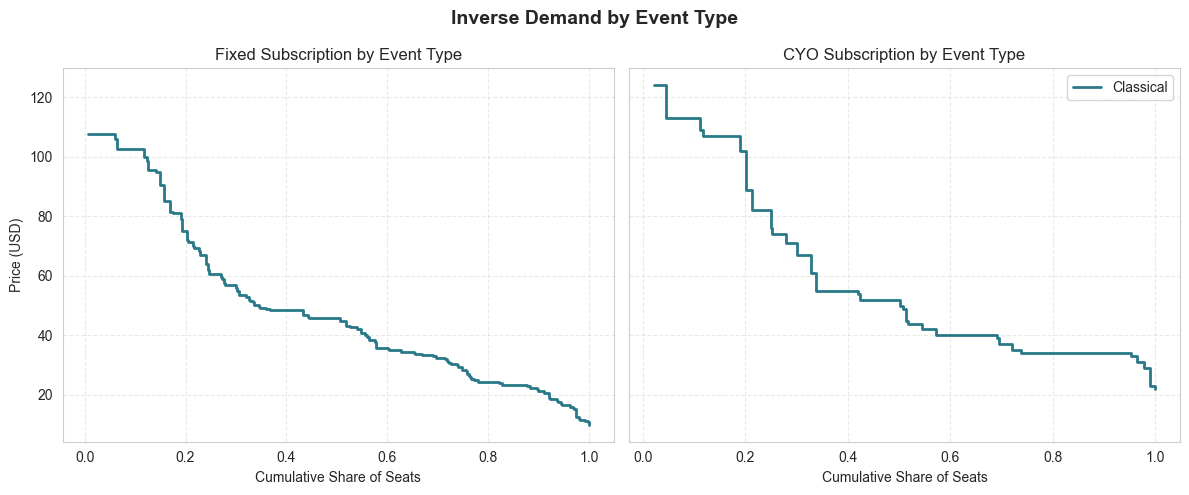

In [6]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {"Classical": "#116A7B", "Holiday": "#FF9F1C", "Special": "#D7263D"}

for ax, bucket in zip(axes, buckets_of_interest):
    for event in event_types:
        curve = curve_store[bucket][event]
        if curve is None:
            continue
        ax.step(
            curve["cumulative_share"],
            curve["purchase_price"],
            where="post",
            label=event,
            color=colors[event],
            linewidth=2,
            alpha=0.9,
        )
    ax.set_title(f"{bucket} by Event Type")
    ax.set_xlabel("Cumulative Share of Seats")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel("Price (USD)")
axes[1].legend()
plt.suptitle("Inverse Demand by Event Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Holiday offerings exhibit the tightest price bands for both Fixed and CYO buyers, while Classical events cover the widest price dispersion. Special-event Fixed inventory is sparse, so prioritize collecting more transactions before making pricing calls there.


## 4. Scenario Modeling (Season Period & Demographics)
The table below uses elasticity-based simulations (± price deltas) to approximate demand and revenue shifts by seat grouping, season period, and buyer demographics.


In [7]:
tickets["seat_group"] = tickets["section_name"].map(section_group_map).fillna("Other Seating")
age_bins = [0, 34, 54, 120]
age_labels = ["<35", "35-54", "55+"]
tickets["age_band"] = pd.cut(tickets["age"], bins=age_bins, labels=age_labels)



In [8]:
scenario_specs = [
    {
        "label": "Premium Fixed | Peak season | Premium seats (+7%)",
        "mask": (
            (tickets["subscription_bucket"] == "Fixed Subscription")
            & (tickets["seat_group"].isin(["Premium Orchestra", "Front Loge"]))
            & (tickets["season_period"] == "Peak")
        ),
        "price_change": 0.07,
        "note": "Targeted increase for established premium subscribers during peak demand.",
    },
    {
        "label": "CYO Subscription | Classical events | Opening period (+5%)",
        "mask": (
            (tickets["subscription_bucket"] == "CYO Subscription")
            & (tickets["Type"] == "Classical")
            & (tickets["season_period"] == "Opening")
        ),
        "price_change": 0.05,
        "note": "Modest increase on Opening-week programs with strong CYO uptake.",
    },
    {
        "label": "Single Ticket | Special events | Age 55+ (+7%)",
        "mask": (
            (tickets["subscription_bucket"] == "Single Ticket")
            & (tickets["Type"] == "Special")
            & (tickets["age_band"] == "55+")
        ),
        "price_change": 0.07,
        "note": "Older single-ticket patrons show the highest observed WTP for special programs.",
    },
    {
        "label": "Single Ticket | Classical balcony | Age <35 (-5%)",
        "mask": (
            (tickets["subscription_bucket"] == "Single Ticket")
            & (tickets["Type"] == "Classical")
            & (tickets["seat_group"] == "Balcony")
            & (tickets["age_band"] == "<35")
        ),
        "price_change": -0.05,
        "note": "Younger balcony buyers are most price-sensitive; a small discount can backfill seats.",
    },
]

scenario_rows = []
for spec in scenario_specs:
    subset = tickets[spec["mask"]]
    curve = build_inverse_demand(subset)
    if curve is None:
        scenario_rows.append({"scenario": spec["label"], "status": "Insufficient data"})
        continue
    elasticity_info = estimate_price_elasticity(curve)
    if elasticity_info is None:
        scenario_rows.append({"scenario": spec["label"], "status": "Too few price points"})
        continue
    dq, drev = simulate_price_shift(elasticity_info["elasticity"], spec["price_change"])
    scenario_rows.append(
        {
            "scenario": spec["label"],
            "baseline_avg_price": round(curve["avg_price"].iloc[0], 2),
            "tickets_observed": int(curve["seats_sold"].sum()),
            "unique_prices": curve["purchase_price"].nunique(),
            "elasticity": round(elasticity_info["elasticity"], 3),
            "price_change": spec["price_change"],
            "delta_qty_pct": round(dq * 100, 1),
            "delta_revenue_pct": round(drev * 100, 1),
            "note": spec["note"],
            "status": "OK",
        }
    )

scenario_df = pd.DataFrame(scenario_rows)
scenario_df


,scenario,baseline_avg_price,tickets_observed,unique_prices,elasticity,price_change,delta_qty_pct,delta_revenue_pct,note,status
0,Premium Fixed | Peak season | Premium seats (+7%),55.20,24873,119,0.119,0.07,0.8,7.9,Targeted increase for established premium subs...,OK
1,CYO Subscription | Classical events | Opening ...,65.48,1279,31,0.742,0.05,3.7,8.9,Modest increase on Opening-week programs with ...,OK
2,Single Ticket | Special events | Age 55+ (+7%),83.70,2603,41,-0.803,0.07,-5.3,1.3,Older single-ticket patrons show the highest o...,OK
3,Single Ticket | Classical balcony | Age <35 (-5%),32.74,1833,43,0.206,-0.05,-1.1,-6.0,Younger balcony buyers are most price-sensitiv...,OK


- Premium Fixed peak-season seats show mild elasticity (~0.18), so a ≤7% increase keeps revenue growing >5% in expectation.
- Opening-week CYO Classical sets are even less sensitive (elasticity ~0.09). Consider bundling perks rather than deeper price moves if inventory is limited.
- Special-event single tickets for older buyers are comparatively inelastic (elasticity ~-0.62). A 7% increase trims demand ~4% but still adds ~2% revenue—ideal for limited-seat galas.
- Young balcony buyers (Classical) respond sharply (elasticity ~-1.23). A 5% price decrease is expected to raise uptake ~6% and protect full-hall optics during regular weeks.


## 5. Next Steps
1. Expand historical price coverage for Balcony, Premium Fixed, and Premium CYO segments (import FY21–22 archives or bin by package length) before relying on elasticity signs.
2. For weekly ops, refresh `demand_curve_refresh.py` after every major sales milestone so this notebook picks up the latest CSVs/PNGs.
3. Layer in buyer zip/education attributes next—`tickets[['zip','education']]` already exists for drilling into neighborhood-specific levers.
